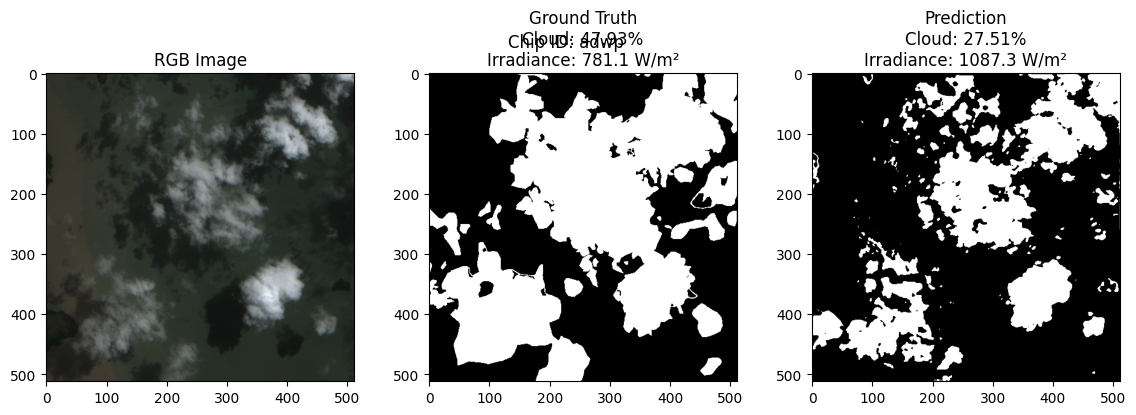

In [37]:
# ================================
# IMPORT LIBRARIES
# ================================

import os
import torch
import torch.nn as nn
import numpy as np
import rasterio
import matplotlib.pyplot as plt


# ================================
# DEVICE
# ================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ================================
# UNET MODEL
# ================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)



class UNet(nn.Module):

    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True
        )

        self.c1 = DoubleConv(in_channels, 16)
        self.c2 = DoubleConv(16, 32)
        self.c3 = DoubleConv(32, 64)
        self.c4 = DoubleConv(64, 128)

        self.bn = DoubleConv(128, 256)

        self.c5 = DoubleConv(256 + 128, 128)
        self.c6 = DoubleConv(128 + 64, 64)
        self.c7 = DoubleConv(64 + 32, 32)
        self.c8 = DoubleConv(32 + 16, 16)

        self.out = nn.Sequential(
            nn.Conv2d(16, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.pool(c1)

        c2 = self.c2(p1)
        p2 = self.pool(c2)

        c3 = self.c3(p2)
        p3 = self.pool(c3)

        c4 = self.c4(p3)
        p4 = self.pool(c4)

        bn = self.bn(p4)

        u4 = self.up(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.c5(u4)

        u3 = self.up(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.c6(u3)

        u2 = self.up(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.c7(u2)

        u1 = self.up(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.c8(u1)

        return self.out(c8)



# ================================
# LOAD MODEL
# ================================

model = UNet(in_channels=4, out_channels=1).to(device)

model.load_state_dict(
    torch.load("pytorch_unet_cloud_30epochfix_256img.pth",
               map_location=device)
)

model.eval()



# ================================
# DATASET PATHS
# ================================

features_dir = r"D:\ML\env\notebook\data\train_features"
labels_dir   = r"D:\ML\env\notebook\data\train_labels"



# ================================
# LOAD CHIP FUNCTION
# ================================

def load_chip(chip_id):

    folder = os.path.join(features_dir, chip_id)

    b02 = rasterio.open(os.path.join(folder,"B02.tif")).read(1)
    b03 = rasterio.open(os.path.join(folder,"B03.tif")).read(1)
    b04 = rasterio.open(os.path.join(folder,"B04.tif")).read(1)
    b08 = rasterio.open(os.path.join(folder,"B08.tif")).read(1)

    mask = rasterio.open(
        os.path.join(labels_dir, chip_id + ".tif")
    ).read(1)

    img = np.stack([b02,b03,b04,b08],axis=0)

    img = img.astype(np.float32)

    img = img / img.max()

    mask = mask > 0

    return img,mask,b02,b03,b04



# ================================
# MODEL PREDICTION
# ================================

def predict_cloud(img):

    x = torch.tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x)

    pred = pred.squeeze().cpu().numpy()

    mask = pred > 0.95

    return mask



# ================================
# CLOUD PERCENTAGE
# ================================

def cloud_percent(mask):

    cloud_pixels = np.sum(mask)

    total_pixels = mask.size

    return (cloud_pixels / total_pixels) * 100



# ================================
# IRRADIANCE ESTIMATION
# ================================

def irradiance_estimate(cloud):

    clearsky = 1500

    return clearsky * (1 - cloud/100)



# ================================
# VISUALIZATION
# ================================

def test_chip(chip_id):

    img,gt,b02,b03,b04 = load_chip(chip_id)

    pred = predict_cloud(img)

    cloud_gt = cloud_percent(gt)

    cloud_pred = cloud_percent(pred)

    irr_gt = irradiance_estimate(cloud_gt)

    irr_pred = irradiance_estimate(cloud_pred)

    rgb = np.stack([b04,b03,b02],axis=-1)

    rgb = rgb / rgb.max()

    plt.figure(figsize=(14,4))

    plt.suptitle(f"Chip ID: {chip_id}")

    plt.subplot(1,3,1)
    plt.title("RGB Image")
    plt.imshow(rgb)

    plt.subplot(1,3,2)
    plt.title(
        f"Ground Truth\n"
        f"Cloud: {cloud_gt:.2f}%\n"
        f"Irradiance: {irr_gt:.1f} W/m²"
    )
    plt.imshow(gt,cmap="gray")

    plt.subplot(1,3,3)
    plt.title(
        f"Prediction\n"
        f"Cloud: {cloud_pred:.2f}%\n"
        f"Irradiance: {irr_pred:.1f} W/m²"
    )
    plt.imshow(pred,cmap="gray")

    plt.show()



# ================================
# RUN TEST
# ================================

test_chip("adwp")